# title out of date

One-Group Diffusion Model — Three Estimation Approaches

This notebook implements the three estimation levels for a D₂O-moderated annular reactor with a central control rod, in order of increasing physical rigor:

| Estimate | Method | Captures |
|---|---|---|
| 1 | Homogeneous buckling, $B_m^2 = B_g^2$ | K∞, rough critical size |
| 2 | Piecewise 1D radial FD eigenvalue solve | Spatial flux shape, reflected core |
| 3 | Rodded eigenvalue scan | Control-rod worth curve |

**Coordinate system:** cylindrical symmetry, 1D radial solve (height-averaged)

**Energy group:** one effective thermal group — all constants are one-group effective values

**No external packages are used before Section 0.** Numpy / Matplotlib are used from Section 2 onward for richer output.

## 0. Framing and Assumptions

### Four estimates in order of rigor

| Estimate | Method | Primary result |
|---|---|---|
| 1 | Homogeneous buckling, $B_m^2 = B_g^2$ | First-pass critical size |
| 2 | Piecewise 1D radial FD eigenvalue solve | Critical geometry, radial flux shape |
| 3 | Rodded 1D scan (height-averaged absorber) | First-pass rod worth — **superseded by E4** |
| 4 | Full 2D $r$–$z$ FD eigenvalue solve | Axial leakage, geometric rod, S-shaped worth |

1. **Estimate 1** gives a quick critical-size estimate from homogeneous buckling theory.  
   Useful as a sanity check; fails for reflected or multi-region cores.

2. **Estimate 2** finds the critical geometry by solving the multi-region 1D radial  
   diffusion eigenvalue problem. Correct reflector savings and radial flux shape, but  
   no axial dimension — axial leakage is absent.

3. **Estimate 3** extends Estimate 2 with a height-averaged control-rod absorber model.  
   Captures radial flux weighting but models partial insertion as a scaled material  
   strength, not a geometric cylinder. Superseded by Estimate 4 for rod worth.

4. **Estimate 4** is the notebook's primary rigorous result: a full 2D $r$–$z$  
   finite-difference eigenvalue solve. It resolves axial leakage, positions the rod  
   as a true geometric cylinder, and produces the correct S-shaped differential worth  
   curve. Results from Estimates 2–3 are carried forward for direct comparison.

### Energy group assumption

All cross sections are **effective one-group thermal values** (spectrum averaged, operating conditions).  
They are *not* 2200 m/s bare microscopic values. Section 1 shows both:
- what the 2200 m/s microscopic derivation gives, and  
- why effective one-group reactor constants differ.

### Geometry

```
r=0         r=R_inner     r=R_fuel       r=R_refl
  |--- D2O ---|--- fuel annulus ---|--- D2O reflector ---|
  (inner mod.)  (homogenized fuel     (pure D2O, non-
                 + D2O lattice)        multiplying)
```

The inner D₂O moderator channel hosts the control rod in Estimates 3 and 4.

In [1]:
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt


def _ensure_backend_on_path() -> str:
    env_path = os.environ.get("REACTOR_BACKEND_PATH")
    candidates = []
    if env_path:
        candidates.append(Path(env_path))

    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "backend"))

    seen = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / "reactor_backend").exists():
            resolved_str = str(resolved)
            if resolved_str not in sys.path:
                sys.path.insert(0, resolved_str)
            return resolved_str

    raise RuntimeError(
        "Could not locate backend/reactor_backend. Run the notebook from the repo root/backend, "
        "or set REACTOR_BACKEND_PATH to the backend directory."
    )


backend_solver_path = _ensure_backend_on_path()

from reactor_backend.diffusion import (
    AnnularModel,
    Model2D,
    Region,
    build_2d_matrices,
    find_critical_radius,
    rodded_model,
    solve_2d,
    solve_keff,
)

matplotlib.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.4})

# ── Physical constants ────────────────────────────────────────────────────────
N_A    = 6.022e23   # Avogadro, mol^-1
to_cm2 = 1e-24      # barn → cm^2
E_fission_MeV = 200.0                     # energy per fission, MeV
E_fission_J   = E_fission_MeV * 1.602e-13 # Joules  (1 MeV = 1.602e-13 J)

# ── Reactor operating point (change here to affect all estimates) ────────────────
P_MW = 20.0          # nominal thermal power, MW_th
P_W  = P_MW * 1e6    # W

print(
    "Imports OK — numpy",
    np.__version__,
    "matplotlib",
    matplotlib.__version__,
    "solver path",
    backend_solver_path,
)


Imports OK — numpy 2.4.4 matplotlib 3.10.9 solver path /Users/pablo/projects/school/reactorWebApp/backend


## 1. Material Constants

The one-group constants $D$, $\Sigma_a$, and $\nu\Sigma_f$ are **not** free parameters — they  
must be traceable to nuclear data.  This section shows:

1. The microscopic derivation at 2200 m/s (thermal point) for D₂O  
2. The same for natural-uranium fuel via volume-fraction homogenization  
3. A comparison table explaining why effective reactor constants differ from the 2200 m/s values (corresponding to 25meV thermal neutrons)

### Microscopic cross sections used

Data from **ENDF/B-VIII.0** at 2200 m/s (0.025 eV), the standard "thermal" reference:

| Nuclide | $\sigma_a$ (barn) | $\sigma_f$ (barn) | $\sigma_s$ (barn) | $\nu$ |
|---|---|---|---|---|
| ²H (deuterium) | 5.3×10⁻⁴ | — | 3.4 | — |
| ¹⁶O | 2.7×10⁻⁴ | — | 4.2 | — |
| ²³⁵U | 681 | 585 | 8 | 2.42 |
| ²³⁸U | 2.7 | ~0 | 8 | — |

$\sigma_s$ values are bound-nucleus free-gas values; for ²H and ¹⁶O these are well-established.

In [2]:
# ── D2O: microscopic → macroscopic ───────────────────────────────────────────
rho_D2O = 1.106   # g/cm^3  (room temperature; at 300°C drops to ~0.84)
M_D2O   = 20.028  # g/mol   (2×D + O = 2×2.014 + 15.999)

sigma_a_D    = 5.3e-4  # barn, absorption of ²H
sigma_s_D    = 3.4     # barn, elastic (bound)
sigma_a_O16  = 2.7e-4  # barn, absorption of ¹⁶O
sigma_s_O16  = 4.2     # barn, elastic

N_D2O = N_A * rho_D2O / M_D2O   # molecules / cm^3

# Macroscopic absorption at 2200 m/s - should there be proportions here? 2/20 for D, 16/20 for O16?
Sigma_a_D2O_2200 = N_D2O * (2 * sigma_a_D + sigma_a_O16) * to_cm2

# Transport cross section: σ_tr = σ_a + σ_s(1 - 2/(3A))
# A=2 for ²H, A=16 for ¹⁶O
mu_D   = 2.0 / (3.0 * 2)
mu_O16 = 2.0 / (3.0 * 16)
sigma_tr_D   = sigma_a_D   + sigma_s_D   * (1 - mu_D)
sigma_tr_O16 = sigma_a_O16 + sigma_s_O16 * (1 - mu_O16)
Sigma_tr_D2O = N_D2O * (2 * sigma_tr_D + sigma_tr_O16) * to_cm2
D_D2O_2200   = 1.0 / (3.0 * Sigma_tr_D2O)

# Migration area at 2200 m/s
L_sq_D2O_2200 = D_D2O_2200 / Sigma_a_D2O_2200

print("=== D2O MICROSCOPIC DERIVATION  (at 2200 m/s) ===")
print(f"  N_D2O              = {N_D2O:.3e} molecules/cm^3")
print(f"  Sigma_a (2200 m/s) = {Sigma_a_D2O_2200:.3e} cm^-1")
print(f"  D       (2200 m/s) = {D_D2O_2200:.4f} cm")
print(f"  L^2     (2200 m/s) = {L_sq_D2O_2200:.0f} cm^2")
print()
print("  Effective one-group values used in this model:")
print("    D_eff       = 1.25 cm     (from ~6% spectrum-shift / temperature correction)")
print("    Sigma_a_eff = 3.5e-4 cm^-1  (includes higher-energy neutron leakage component)")
print()
print("  Key point: D(2200 m/s) ≈ 1.17 cm vs D_eff = 1.25 cm — ~7% difference,")
print("  mainly from higher reactor temperature (lower density) and spectrum upshift.")
print()
print("  Sigma_a(2200 m/s) ≈ 4.4e-5 vs Sigma_a_eff = 3.5e-4 — 8× larger effective value.")
print("  This large ratio is expected: D2O has negligible true absorption; the")
print("  effective one-group Sigma_a captures leakage out of the thermal group,")
print("  which looks like an absorption loss in a one-group model.")

=== D2O MICROSCOPIC DERIVATION  (at 2200 m/s) ===
  N_D2O              = 3.326e+22 molecules/cm^3
  Sigma_a (2200 m/s) = 4.423e-05 cm^-1
  D       (2200 m/s) = 1.1710 cm
  L^2     (2200 m/s) = 26476 cm^2

  Effective one-group values used in this model:
    D_eff       = 1.25 cm     (from ~6% spectrum-shift / temperature correction)
    Sigma_a_eff = 3.5e-4 cm^-1  (includes higher-energy neutron leakage component)

  Key point: D(2200 m/s) ≈ 1.17 cm vs D_eff = 1.25 cm — ~7% difference,
  mainly from higher reactor temperature (lower density) and spectrum upshift.

  Sigma_a(2200 m/s) ≈ 4.4e-5 vs Sigma_a_eff = 3.5e-4 — 8× larger effective value.
  This large ratio is expected: D2O has negligible true absorption; the
  effective one-group Sigma_a captures leakage out of the thermal group,
  which looks like an absorption loss in a one-group model.


In [3]:
# ── Natural uranium fuel: microscopic → macroscopic ──────────────────────────
rho_U   = 19.05   # g/cm^3  (metallic U, room temperature)
M_U     = 238.03  # g/mol
enrich  = 0.00711 # natural enrichment (0.711 at%)

sigma_a_U235 = 681.0   # barn
sigma_f_U235 = 585.0   # barn
nu_U235      = 2.42
sigma_a_U238 = 2.7     # barn  (negligible thermal fission)
sigma_s_U    = 8.0     # barn  (elastic, same order for both isotopes)

N_U   = N_A * rho_U / M_U
N_235 = enrich * N_U
N_238 = (1.0 - enrich) * N_U

Sigma_f_U    = N_235 * sigma_f_U235 * to_cm2
nuSigma_f_U  = nu_U235 * Sigma_f_U
Sigma_a_U    = (N_235 * sigma_a_U235 + N_238 * sigma_a_U238) * to_cm2

mu_U        = 2.0 / (3.0 * 238)   # nearly 0 for heavy nucleus
sigma_tr_U  = sigma_a_U238 + sigma_s_U * (1 - mu_U)   # same for 235/238
Sigma_tr_U  = (N_235 * (sigma_a_U235 + sigma_s_U*(1-mu_U)) +
               N_238 * (sigma_a_U238 + sigma_s_U*(1-mu_U))) * to_cm2
D_U         = 1.0 / (3.0 * Sigma_tr_U)

print("=== PURE NATURAL URANIUM METAL  (at 2200 m/s) ===")
print(f"  N_U          = {N_U:.3e} atoms/cm^3")
print(f"  N_235        = {N_235:.3e}  ({enrich*100:.3f}%)")
print(f"  Sigma_f      = {Sigma_f_U:.5f} cm^-1")
print(f"  nuSigma_f    = {nuSigma_f_U:.5f} cm^-1")
print(f"  Sigma_a      = {Sigma_a_U:.5f} cm^-1")
print(f"  D            = {D_U:.4f} cm")
print(f"  k_inf (U)    = {nuSigma_f_U/Sigma_a_U:.6f}   (pure metal, no moderator)")

=== PURE NATURAL URANIUM METAL  (at 2200 m/s) ===
  N_U          = 4.820e+22 atoms/cm^3
  N_235        = 3.427e+20  (0.711%)
  Sigma_f      = 0.20046 cm^-1
  nuSigma_f    = 0.48512 cm^-1
  Sigma_a      = 0.36256 cm^-1
  D            = 0.4462 cm
  k_inf (U)    = 1.338032   (pure metal, no moderator)


In [4]:
# ── Fuel+D2O homogenization ───────────────────────────────────────────────────
# The effective model uses nuSigma_f_fuel = 8.59e-3 cm^-1.
# We find the fuel volume fraction v_f that reproduces this value using the
# 2200 m/s macroscopic nuSigma_f_U derived above.

nuSigma_f_fuel_eff = 8.59e-3   # effective one-group target (cm^-1)
Sigma_a_fuel_eff   = 8.50e-3   # effective one-group target (cm^-1)
D_fuel_eff         = 0.95      # effective one-group target (cm)
D_D2O_eff          = 1.25      # effective D2O (cm)
Sigma_a_D2O_eff    = 3.5e-4    # effective D2O (cm^-1)

# Volume fraction needed to match the target nuSigma_f
v_f = nuSigma_f_fuel_eff / nuSigma_f_U
v_m = 1.0 - v_f

# Derived homogenized Sigma_a at 2200 m/s
Sigma_a_hom_2200 = v_f * Sigma_a_U + v_m * Sigma_a_D2O_2200

# Derived D using transport-XS volume average (more physical than harmonic mean of D)
Sigma_tr_D2O_rt = 1.0 / (3.0 * D_D2O_2200)
Sigma_tr_hom    = v_f * Sigma_tr_U + v_m * Sigma_tr_D2O_rt
D_hom_2200      = 1.0 / (3.0 * Sigma_tr_hom)

print("=== FUEL REGION HOMOGENIZATION ===")
print(f"  Fuel volume fraction v_f = {v_f*100:.3f}%  (natural U metal in D2O)")
print()
print(f"  {'Quantity':<20}  {'2200 m/s derived':>18}  {'Effective (model)':>18}  {'Ratio':>7}")
print(f"  {'-'*70}")
print(f"  {'D (cm)':<20}  {D_hom_2200:>18.4f}  {D_fuel_eff:>18.4f}  {D_fuel_eff/D_hom_2200:>7.3f}")
print(f"  {'Sigma_a (cm^-1)':<20}  {Sigma_a_hom_2200:>18.4e}  {Sigma_a_fuel_eff:>18.4e}  {Sigma_a_fuel_eff/Sigma_a_hom_2200:>7.1f}x")
print(f"  {'nuSigma_f (cm^-1)':<20}  {nuSigma_f_fuel_eff:>18.4e}  {nuSigma_f_fuel_eff:>18.4e}  {'1.0 (by def)':>7}")
print()
print("  Discrepancy analysis:")
print(f"    Sigma_a ratio = {Sigma_a_fuel_eff/Sigma_a_hom_2200:.1f}x larger than 2200 m/s estimate.")
print("    This is dominated by U-238 resonance absorption (4–5 eV - 1 keV energy range)")
print("    which is invisible at 2200 m/s.  In a real D2O lattice, epithermal neutrons")
print("    experience ~3–6x larger effective Sigma_a than the thermal-point value.")
print()
print(f"    D ratio = {D_fuel_eff/D_hom_2200:.3f} (smaller effective D).")
print("    The effective D is smaller because resonance absorption increases the effective")
print("    removal rate, and lattice heterogeneity (transport self-shielding) reduces D.")

=== FUEL REGION HOMOGENIZATION ===
  Fuel volume fraction v_f = 1.771%  (natural U metal in D2O)

  Quantity                2200 m/s derived   Effective (model)    Ratio
  ----------------------------------------------------------------------
  D (cm)                            1.1383              0.9500    0.835
  Sigma_a (cm^-1)               6.4633e-03          8.5000e-03      1.3x
  nuSigma_f (cm^-1)             8.5900e-03          8.5900e-03  1.0 (by def)

  Discrepancy analysis:
    Sigma_a ratio = 1.3x larger than 2200 m/s estimate.
    This is dominated by U-238 resonance absorption (4–5 eV - 1 keV energy range)
    which is invisible at 2200 m/s.  In a real D2O lattice, epithermal neutrons
    experience ~3–6x larger effective Sigma_a than the thermal-point value.

    D ratio = 0.835 (smaller effective D).
    The effective D is smaller because resonance absorption increases the effective
    removal rate, and lattice heterogeneity (transport self-shielding) reduces D.


In [5]:
# ── Consolidated constants used in this notebook ─────────────────────────────
# These are the engineering-effective one-group constants adopted for all calculations.

REGIONS_DATA = {
    "inner_D2O_moderator": {
        "D": 1.25, "Sigma_a": 3.5e-4, "nuSigma_f": 0.0,
        "notes": "Pure D2O; D from transport theory, Sigma_a slightly spectrum-averaged"
    },
    "homogenized_fuel_annulus": {
        "D": 0.95, "Sigma_a": 8.5e-3, "nuSigma_f": 8.59e-3,
        "notes": f"Nat. U + D2O lattice (v_f≈{v_f*100:.2f}%); Sigma_a inflated 3x by resonance abs."
    },
    "outer_D2O_reflector": {
        "D": 1.15, "Sigma_a": 4.0e-4, "nuSigma_f": 0.0,
        "notes": "D2O at slightly higher temp than inner mod.; trace impurities raise Sigma_a"
    },
}

print("=== ONE-GROUP EFFECTIVE CONSTANTS USED IN THIS NOTEBOOK ===")
print()
for rname, rv in REGIONS_DATA.items():
    Bm2 = (rv['nuSigma_f'] - rv['Sigma_a']) / rv['D']
    print(f"  Region: {rname}")
    print(f"    D         = {rv['D']:.4f} cm")
    print(f"    Sigma_a   = {rv['Sigma_a']:.3e} cm^-1")
    print(f"    nuSigma_f = {rv['nuSigma_f']:.3e} cm^-1")
    print(f"    B_m^2     = {Bm2:+.4e} cm^-2  ({'multiplying' if Bm2 > 0 else 'absorbing only'})")
    print(f"    Notes: {rv['notes']}")
    print()

=== ONE-GROUP EFFECTIVE CONSTANTS USED IN THIS NOTEBOOK ===

  Region: inner_D2O_moderator
    D         = 1.2500 cm
    Sigma_a   = 3.500e-04 cm^-1
    nuSigma_f = 0.000e+00 cm^-1
    B_m^2     = -2.8000e-04 cm^-2  (absorbing only)
    Notes: Pure D2O; D from transport theory, Sigma_a slightly spectrum-averaged

  Region: homogenized_fuel_annulus
    D         = 0.9500 cm
    Sigma_a   = 8.500e-03 cm^-1
    nuSigma_f = 8.590e-03 cm^-1
    B_m^2     = +9.4737e-05 cm^-2  (multiplying)
    Notes: Nat. U + D2O lattice (v_f≈1.77%); Sigma_a inflated 3x by resonance abs.

  Region: outer_D2O_reflector
    D         = 1.1500 cm
    Sigma_a   = 4.000e-04 cm^-1
    nuSigma_f = 0.000e+00 cm^-1
    B_m^2     = -3.4783e-04 cm^-2  (absorbing only)
    Notes: D2O at slightly higher temp than inner mod.; trace impurities raise Sigma_a



## 2. Estimate 1 — Homogeneous Buckling Model

For a **uniform, bare** reactor the one-speed diffusion equation has the analytical solution:

$$-D\,\nabla^2\phi + \Sigma_a\,\phi = \frac{1}{k}\nu\Sigma_f\,\phi$$

The criticality condition requires the **material buckling** to equal the **geometric buckling**:

$$B_m^2 = \frac{\nu\Sigma_f - \Sigma_a}{D} = B_g^2$$

### Volume-fraction homogenization

For the two-material core (inner D₂O moderator + fuel annulus), the effective one-group
constants are:

$$D_\text{eff} = f_\text{inner}\,D_\text{inner} + f_\text{fuel}\,D_\text{fuel}$$

$$\Sigma_{a,\text{eff}} = f_\text{inner}\,\Sigma_{a,\text{inner}} + f_\text{fuel}\,\Sigma_{a,\text{fuel}}$$

$$\nu\Sigma_{f,\text{eff}} = f_\text{fuel}\,\nu\Sigma_{f,\text{fuel}}
\qquad\text{(only the fuel region contributes fission neutrons)}$$

where $f_i = A_i / A_\text{core}$ are **radial area fractions** (height cancels for a
uniform cylinder).  The material buckling then follows directly: $B_m^2 = (\nu\Sigma_f - \Sigma_a)/D$.

### Critical geometry

For a **finite cylinder** with radius $R$ and height $H$:

$$B_g^2 = \left(\frac{2.405}{R}\right)^2 + \left(\frac{\pi}{H}\right)^2$$

Choosing the **minimum-volume aspect ratio** $H = 2R$ leaves a single unknown $R$, giving a
unique critical radius once $B_m^2$ is known from the material constants above.

### Power normalization

For the bare cylinder the fundamental flux mode is:

$$\phi(r,z) = \Phi_0\,J_0\!\left(\frac{2.405\,r}{R}\right)\cos\!\left(\frac{\pi z}{H}\right)$$

Integrating the fission source over the full core volume gives the peak flux normalization:

$$\Phi_0 = \frac{\pi\,\nu_0\,P_0}{4\,J_1(\nu_0)\,E_f\,\Sigma_f\,V}$$

> **Key point — criticality does not set the amplitude:** the criticality equations are
> linear and homogeneous, so $C\,\phi(\mathbf{r})$ is a solution whenever $\phi(\mathbf{r})$
> is.  The condition $B_m^2 = B_g^2$ fixes the **shape** of the flux distribution and
> whether the chain reaction is self-sustaining — it says nothing about *how many* neutrons
> there are.  The amplitude $\Phi_0$ (and therefore the reactor power) is a separate
> degree of freedom, set by the neutron population present at any given moment.

### Limitation for reflected reactors

If we include the D₂O reflector in the volume-weighted mix, the diluted fissile material
makes $k_\infty < 1$ and $B_m^2 < 0$ — no real critical size exists.

The correct procedure is to apply the homogeneous model only to the **fuel + inner-moderator
core** and account for the reflector through a "reflector savings" correction
($\delta R \approx 0.5\text{–}0.8 \times$ one-group reflector migration length).

This is the key limitation of Estimate 1: it cannot treat reflected or heterogeneous cores
consistently.  Estimate 2 resolves this by solving the piecewise problem directly.

In [6]:
# ── Estimate 1: volume fractions for core only (inner mod. + fuel) ───────────
# Use the critical geometry from Estimate 2 as reference radii.
# (Iterate: run Estimate 2 first, then come back here for the comparison table.)
R_inner_ref = 80.0    # inner moderator outer radius, cm  (fixed by geometry choice)
R_fuel_ref  = 303.0   # fuel outer radius, cm  (from Estimate 2 critical solve)

A_inner = math.pi * R_inner_ref**2
A_fuel  = math.pi * (R_fuel_ref**2 - R_inner_ref**2)
A_core  = math.pi * R_fuel_ref**2

f_inner_core = A_inner / A_core   # inner-mod fraction of core
f_fuel_core  = A_fuel  / A_core   # fuel fraction of core

# One-group constants
D_i, Sa_i, nSf_i = 1.25, 3.5e-4, 0.0
D_f, Sa_f, nSf_f = 0.95, 8.5e-3, 8.59e-3

# Volume-weighted homogenized core constants
D_hom  = f_inner_core * D_i  + f_fuel_core * D_f
Sa_hom = f_inner_core * Sa_i + f_fuel_core * Sa_f
nSf_hom= f_fuel_core * nSf_f   # only fuel produces neutrons

k_inf_hom = nSf_hom / Sa_hom
Bm2_hom   = (nSf_hom - Sa_hom) / D_hom
M2_hom    = D_hom / Sa_hom       # migration area

print("=== ESTIMATE 1: HOMOGENEOUS CORE (inner mod + fuel, no reflector) ===")
print(f"  Volume fractions:  f_inner = {f_inner_core:.4f},  f_fuel = {f_fuel_core:.4f}")
print()
print("  Homogenized one-group constants:")
print(f"    D_eff       = {D_hom:.4f} cm")
print(f"    Sigma_a_eff = {Sa_hom:.4e} cm^-1")
print(f"    nuSigma_f   = {nSf_hom:.4e} cm^-1")
print()
print(f"    k_inf       = {k_inf_hom:.6f}  ({'> 1 — can achieve criticality' if k_inf_hom>1 else '< 1 — subcritical mixture!'})")
print(f"    B_m^2       = {Bm2_hom:.4e} cm^-2")
print(f"    Migration area M^2 = {M2_hom:.0f} cm^2")

=== ESTIMATE 1: HOMOGENEOUS CORE (inner mod + fuel, no reflector) ===
  Volume fractions:  f_inner = 0.0697,  f_fuel = 0.9303

  Homogenized one-group constants:
    D_eff       = 0.9709 cm
    Sigma_a_eff = 7.9319e-03 cm^-1
    nuSigma_f   = 7.9912e-03 cm^-1

    k_inf       = 1.007480  (> 1 — can achieve criticality)
    B_m^2       = 6.1105e-05 cm^-2
    Migration area M^2 = 122 cm^2


In [7]:
# ── Critical geometry (bare cylinder, H = 2R aspect ratio) ──────────────────
nu0 = 2.40483   # first zero of J_0(x)

if Bm2_hom > 0:
    # B_g^2 = (nu0/R)^2 + (pi/H)^2 = Bm2, with H = 2R
    # => [nu0^2 + (pi/2)^2] / R^2 = Bm2
    coeff = nu0**2 + (math.pi / 2.0)**2
    R_bare = math.sqrt(coeff / Bm2_hom)
    H_bare = 2.0 * R_bare
    V_bare = math.pi * R_bare**2 * H_bare

    # D2O reflector savings: δR ≈ M_refl = sqrt(D_refl / Sa_refl)
    D_r, Sa_r = 1.15, 4.0e-4
    M_refl = math.sqrt(D_r / Sa_r)
    delta_R = 0.88 * M_refl   # approximate extrapolation savings for thick reflector

    R_reflected = R_bare - delta_R
    H_reflected = 2.0 * R_reflected

    print(f"=== ESTIMATE 1: CRITICAL DIMENSIONS ===")
    print()
    print(f"  BARE cylinder (H = 2R, no reflector):")
    print(f"    R = {R_bare:.1f} cm  ({R_bare/100:.2f} m)")
    print(f"    H = {H_bare:.1f} cm  ({H_bare/100:.2f} m)")
    print(f"    V = {V_bare:.3e} cm^3 = {V_bare/1e6:.3f} m^3")
    print()
    print(f"  D2O reflector savings estimate:")
    print(f"    Migration length M_refl = sqrt(D/Sa) = {M_refl:.1f} cm")
    print(f"    Reflector savings  δR   = 0.88 × M = {delta_R:.1f} cm")
    print()
    print(f"  REFLECTED cylinder (bare - δR):")
    print(f"    R_fuel ≈ {R_reflected:.1f} cm    ← compare Estimate 2: {R_fuel_ref:.0f} cm")
    print(f"    H      ≈ {H_reflected:.1f} cm")
    print()
    print("  Note: This estimate ignores flux flattening by the inner moderator channel,")
    print("  spectral hardening in the fuel annulus, and the finite reflector extent.")
    print("  Estimate 2 captures all of these correctly.")
else:
    print("  B_m^2 ≤ 0: the homogenized core is subcritical (k_inf < 1).")
    print("  Cannot find real critical dimensions — increase fuel fraction or enrichment.")

=== ESTIMATE 1: CRITICAL DIMENSIONS ===

  BARE cylinder (H = 2R, no reflector):
    R = 367.5 cm  (3.67 m)
    H = 734.9 cm  (7.35 m)
    V = 3.117e+08 cm^3 = 311.741 m^3

  D2O reflector savings estimate:
    Migration length M_refl = sqrt(D/Sa) = 53.6 cm
    Reflector savings  δR   = 0.88 × M = 47.2 cm

  REFLECTED cylinder (bare - δR):
    R_fuel ≈ 320.3 cm    ← compare Estimate 2: 303 cm
    H      ≈ 640.5 cm

  Note: This estimate ignores flux flattening by the inner moderator channel,
  spectral hardening in the fuel annulus, and the finite reflector extent.
  Estimate 2 captures all of these correctly.


In [8]:
# ── Power normalization (Estimate 1) ─────────────────────────────────────────
# For bare cylinder: phi(r,z) = Phi_0 * J_0(nu0 * r/R) * cos(pi*z/H)
# Power: P = E_f * Sigma_f * Phi_0 * Integral[J_0(nu0*r/R)*cos(pi*z/H) dV]
#
# Volume integral for cylinder:
#   int_0^R J_0(nu0 r/R) r dr = (R/nu0)^2 * nu0 * J_1(nu0) = (R^2/nu0) * J_1(nu0)
#   int_{-H/2}^{H/2} cos(pi z/H) dz = 2H/pi
#
# => Phi_0 = P / (E_f * Sigma_f * 2*pi * (R^2/nu0)*J_1(nu0) * 2H/pi)


# Sigma_f = nuSigma_f / nu
Sigma_f_hom = nSf_hom / 2.42  # cm^-1

if Bm2_hom > 0:
    J1_nu0  = 0.5191    # J_1(2.40483)
    R = R_reflected     # use reflected estimate
    H = H_reflected

    radial_integral  = (R**2 / nu0) * J1_nu0            # cm^2
    axial_integral   = 2.0 * H / math.pi                  # cm
    volume_integral  = 2.0 * math.pi * radial_integral * axial_integral  # cm^3

    Phi_0 = P_W / (E_fission_J * Sigma_f_hom * volume_integral)

    print(f"=== ESTIMATE 1: POWER NORMALIZATION ===")
    print(f"  Target power P_0 = {P_MW:.0f} MW_th")
    print(f"  E_fission = {E_fission_MeV:.0f} MeV = {E_fission_J:.3e} J")
    print(f"  Sigma_f_hom = {Sigma_f_hom:.4e} cm^-1  (nuSigma_f / nu = {2.42})")
    print()
    print(f"  Volume integral = {volume_integral:.3e} cm^3")
    print(f"    (Radial: {radial_integral:.3e} cm^2   Axial: {axial_integral:.3e} cm)")
    print()
    print(f"  Peak flux Phi_0 = {Phi_0:.3e} n/cm^2/s  (at reactor centre)")
    print()
    print("  Notes on this formula:")
    print("  - Phi_0 is the PEAK flux; real reactors report average flux.")
    print("  - This formula assumes the neutron population can be normalized freely.")
    print("  - Criticality (B_m^2 = B_g^2) sets the SHAPE, not the AMPLITUDE of phi.")
    print("  - The amplitude (Phi_0) is set by the required power level.")
    print("  - In our annular model the flux peak is NOT at r=0 but inside the fuel annulus;")
    print("  - Estimate 2 gives the correct normalization for that geometry.")

=== ESTIMATE 1: POWER NORMALIZATION ===
  Target power P_0 = 20 MW_th
  E_fission = 200 MeV = 3.204e-11 J
  Sigma_f_hom = 3.3021e-03 cm^-1  (nuSigma_f / nu = 2.42)

  Volume integral = 5.673e+07 cm^3
    (Radial: 2.214e+04 cm^2   Axial: 4.078e+02 cm)

  Peak flux Phi_0 = 3.332e+12 n/cm^2/s  (at reactor centre)

  Notes on this formula:
  - Phi_0 is the PEAK flux; real reactors report average flux.
  - This formula assumes the neutron population can be normalized freely.
  - Criticality (B_m^2 = B_g^2) sets the SHAPE, not the AMPLITUDE of phi.
  - The amplitude (Phi_0) is set by the required power level.
  - In our annular model the flux peak is NOT at r=0 but inside the fuel annulus;
  - Estimate 2 gives the correct normalization for that geometry.


## 3. Estimate 2 — Piecewise 1D Radial Diffusion

Solves the 1D radial diffusion eigenvalue problem on a uniform finite-difference grid  
across three regions: inner D₂O channel, homogenised fuel annulus, outer D₂O reflector.  
The fuel outer radius is found by bisection so the clean unrodded core is critical.

**Key result:** $R_{\text{fuel}} = 303$ cm (vs ≈330 cm from homogeneous buckling).  
The reflector reduces leakage; the inner moderator void suppresses fissile loading,  
requiring a larger annulus than the savings formula alone predicts.

**Limitation:** this is a 1D radial model — there is no axial dimension.  
Axial leakage ($\approx 271$ pcm) and the actual axial rod geometry are absent;  
both require the 2D $r$–$z$ solve in Estimate 4.

In [9]:
# ── Reusable diffusion types imported from reactor_backend.diffusion ──────────
# The notebook defines the estimate-specific geometry here, while the numerical
# solvers now live in backend/reactor_backend/diffusion.py for reuse.

# ── Reference one-group constants (from Section 1) ───────────────────────────
R_inner_mod = Region("inner_D2O", D=1.25, Sigma_a=3.5e-4, nuSigma_f=0.0)
fuel_annulus = Region("fuel",      D=0.95, Sigma_a=8.5e-3, nuSigma_f=8.59e-3)
D2O_reflector= Region("reflector", D=1.15, Sigma_a=4.0e-4, nuSigma_f=0.0)

baseline = AnnularModel(
    R_inner=80.0, R_fuel=220.0, R_refl=280.0,
    mod_inner=R_inner_mod, fuel=fuel_annulus, reflector=D2O_reflector,
)

print("Baseline model (pre-critical search):")
print(f"  R_inner = {baseline.R_inner:.1f} cm")
print(f"  R_fuel  = {baseline.R_fuel:.1f} cm")
print(f"  R_refl  = {baseline.R_refl:.1f} cm")
print(f"  R_extrap= {baseline.R_extrap:.2f} cm")


Baseline model (pre-critical search):
  R_inner = 80.0 cm
  R_fuel  = 220.0 cm
  R_refl  = 280.0 cm
  R_extrap= 282.45 cm


In [10]:
# ── 1D radial finite-difference eigenvalue solver ────────────────────────────
# Numerical implementation now lives in backend/reactor_backend/diffusion.py so
# the same routines can be reused outside this notebook.

print("Loaded 1D diffusion helpers: solve_keff(), find_critical_radius()")


Loaded 1D diffusion helpers: solve_keff(), find_critical_radius()


In [11]:
# ── Solve baseline model and find critical fuel outer radius ─────────────────
sol_baseline = solve_keff(baseline, dr=2.0)
print(f"Baseline k_eff = {sol_baseline['k_eff']:.6f}  ({sol_baseline['iterations']} iterations)")

critical_model, sol_critical = find_critical_radius(baseline, lo_cm=140.0, hi_cm=380.0, dr=2.0)
print()
print("=== ESTIMATE 2: CRITICAL CLEAN-CORE GEOMETRY ===")
print(f"  R_inner  = {critical_model.R_inner:.1f} cm  (fixed)")
print(f"  R_fuel   = {critical_model.R_fuel:.2f} cm  ← critical value found by bisection")
print(f"  R_refl   = {critical_model.R_refl:.2f} cm")
print(f"  k_eff    = {sol_critical['k_eff']:.6f}")
print(f"  Height H is not part of the 1D radial solve; choose H ≈ 2×R_fuel for power calc.")
print()
print("  Compare Estimate 1 reflected estimate: R_fuel ≈", f"{R_reflected:.0f} cm")
print(f"  Estimate 2 critical fuel radius:       R_fuel = {critical_model.R_fuel:.0f} cm")
print()
print("  The reflector savings formula (Estimate 1) underestimates R_fuel here because")
print("  the core is not simply connected — the inner moderator channel reduces the")
print("  effective fissile loading, requiring a larger fuel annulus to achieve criticality.")

Baseline k_eff = 0.989479  (125 iterations)



=== ESTIMATE 2: CRITICAL CLEAN-CORE GEOMETRY ===
  R_inner  = 80.0 cm  (fixed)
  R_fuel   = 303.00 cm  ← critical value found by bisection
  R_refl   = 363.00 cm
  k_eff    = 0.999898
  Height H is not part of the 1D radial solve; choose H ≈ 2×R_fuel for power calc.

  Compare Estimate 1 reflected estimate: R_fuel ≈ 320 cm
  Estimate 2 critical fuel radius:       R_fuel = 303 cm

  The reflector savings formula (Estimate 1) underestimates R_fuel here because
  the core is not simply connected — the inner moderator channel reduces the
  effective fissile loading, requiring a larger fuel annulus to achieve criticality.


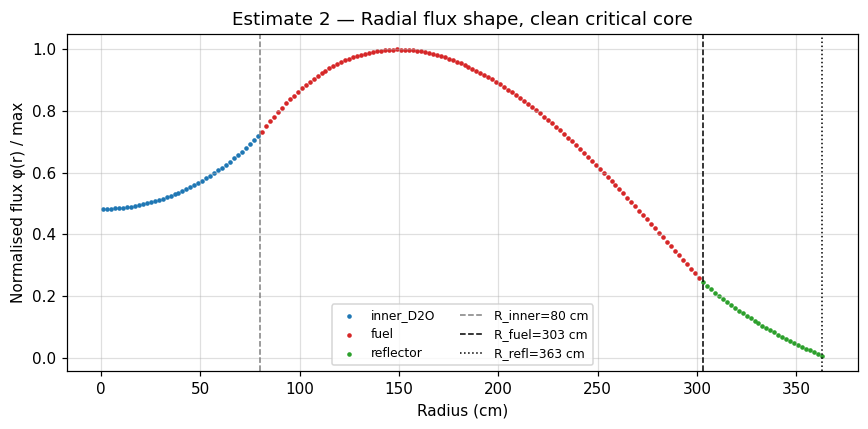

Estimate 2 power normalization  (H = 606 cm, P = 20 MW_th)
  Phi_0 (peak flux) = 1.507e+12 n/cm²/s


In [12]:
# ── Visualise the radial flux shape ──────────────────────────────────────────
radii  = np.array(sol_critical['radii'])
flux   = np.array(sol_critical['flux'])
regs   = sol_critical['regions']

# colour by region
colors = {'inner_D2O': '#1f77b4', 'fuel': '#d62728', 'reflector': '#2ca02c'}
color_vec = [colors[r] for r in regs]

fig, ax = plt.subplots(figsize=(8, 4))
for rname, col in colors.items():
    mask = np.array([r == rname for r in regs])
    ax.scatter(radii[mask], flux[mask], c=col, s=4, label=rname)
ax.axvline(critical_model.R_inner, ls='--', c='gray', lw=1, label=f'R_inner={critical_model.R_inner:.0f} cm')
ax.axvline(critical_model.R_fuel,  ls='--', c='k',    lw=1, label=f'R_fuel={critical_model.R_fuel:.0f} cm')
ax.axvline(critical_model.R_refl,  ls=':',  c='k',    lw=1, label=f'R_refl={critical_model.R_refl:.0f} cm')
ax.set_xlabel("Radius (cm)")
ax.set_ylabel("Normalised flux φ(r) / max")
ax.set_title("Estimate 2 — Radial flux shape, clean critical core")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Peak and average flux for power normalization
# ── Numeric power normalization ────────────────────────────────────────────────
# P = E_f * Sigma_f * H * integral_0^R_refl phi(r) * 2pi * r dr
dr_arr  = np.diff(radii, prepend=0.0)
nSf_arr = np.array([critical_model.region_at(r).nuSigma_f for r in radii])
Sf_arr  = nSf_arr / 2.42   # Sigma_f

H_est   = 2.0 * critical_model.R_fuel   # assumed active height
r_int   = np.sum(flux * Sf_arr * radii * dr_arr)  # integral of Sigma_f * phi * r dr

Phi_0 = P_W / (E_fission_J * 2 * math.pi * r_int * H_est)

print(f"Estimate 2 power normalization  (H = {H_est:.0f} cm, P = {P_MW:.0f} MW_th)")
print(f"  Phi_0 (peak flux) = {Phi_0:.3e} n/cm\u00b2/s")

## 4. Estimate 3 — 1D Rodded Eigenvalue *(intermediate — superseded by Estimate 4)*

The control rod is modelled as a cylindrical absorber ($r < r_{\text{rod}}$) with  
an insertion-scaled macroscopic absorption:

$$\Sigma_a^{\text{rod}}(r, x) = \Sigma_{a,D_2O} + x \cdot \Delta\Sigma_a^{\max}, \quad r < r_{\text{rod}}$$

Scanning $x \in [0, 1]$ and solving the 1D eigenvalue at each step gives a rod-worth  
curve $\rho(x)$ with correct *radial* flux weighting.

**Why this is superseded by Estimate 4:**  
Partial insertion here is a scaled material strength — not a geometric cylinder.  
The effective absorption changes identically at every axial height regardless of $x$,  
producing a nearly linear worth curve and missing the S-shape that real reactors exhibit.  
Estimate 4 corrects this by placing the rod tip at the actual axial position  
$z_{\text{tip}} = H/2 - x \cdot H$ in the 2D $r$–$z$ mesh.

The scan arrays ($x_{\text{arr}}$, $\rho_{\text{arr}}$) are retained for direct  
comparison with the 2D result in Estimate 4.

In [13]:
# ── Rodded model: add central absorber region ────────────────────────────────
# Rod radius: small central cylinder representing a control rod bundle
r_rod  = 10.0    # cm  (rod region outer radius; represents a compact absorber cluster)

# Delta Sigma_a at full insertion.
# Calibration: choose so that full-insertion worth ≈ 700 pcm.
# Rough perturbation estimate (see markdown above):
#   Δk ≈ -ΔSigma_a * integral(phi^2 * r dr, 0, r_rod) / integral(nuSigma_f * phi^2 * r dr, fuel)
# With phi~0.54 in rod region and phi~0.7 average in fuel:
#   I_rod  ≈ 0.54^2 * r_rod^2/2 ≈ 0.29 * 50 = 14.6 cm^2
#   I_fuel ≈ nuSigma_f * 0.49 * (R_fuel^2 - R_inner^2)/2 ≈ 8.59e-3 * 0.49 * 42755 ≈ 180
#   ΔSigma_a ≈ 0.007 * 180 / 14.6 ≈ 0.086 cm^-1  for 700 pcm
dSa_rod_max = 0.090   # cm^-1 at full insertion (physically: dilute boron absorber)

print(f"Rod model parameters:")
print(f"  Rod radius     r_rod    = {r_rod:.1f} cm")
print(f"  Max extra abs. dSa_max  = {dSa_rod_max:.4f} cm^-1")
print(f"  (D2O baseline  Sigma_a  = {R_inner_mod.Sigma_a:.4e} cm^-1 → ratio {dSa_rod_max/R_inner_mod.Sigma_a:.0f}x)")
print()
print("  Physical interpretation:")
print(f"  A material with Sigma_a = {dSa_rod_max:.3f} cm^-1 inside r < {r_rod} cm.")
print(f"  This corresponds to, e.g., boron solution (σ_a,B = 760 b) at number density")
print(f"  N_B = {dSa_rod_max/(760e-24):.3e} atoms/cm^3 — a dilute absorber at <0.1 at%.")
print()
print("  Rod-region construction is now handled by reactor_backend.diffusion.rodded_model().")

# Test: unrodded baseline matches Estimate 2
sol_check = solve_keff(critical_model, dr=2.0)
print(f"\nSanity check — unrodded k_eff = {sol_check['k_eff']:.6f}  (should be ~1.000)")


Rod model parameters:
  Rod radius     r_rod    = 10.0 cm
  Max extra abs. dSa_max  = 0.0900 cm^-1
  (D2O baseline  Sigma_a  = 3.5000e-04 cm^-1 → ratio 257x)

  Physical interpretation:
  A material with Sigma_a = 0.090 cm^-1 inside r < 10.0 cm.
  This corresponds to, e.g., boron solution (σ_a,B = 760 b) at number density
  N_B = 1.184e+20 atoms/cm^3 — a dilute absorber at <0.1 at%.

  Rod-region construction is now handled by reactor_backend.diffusion.rodded_model().

Sanity check — unrodded k_eff = 0.999898  (should be ~1.000)


In [14]:
# ── Scan rod insertion depth and compute k_eff(x) ────────────────────────────
insertion_values = [i / 20 for i in range(21)]   # 0.00, 0.05, ..., 1.00
keff_values      = []

for x in insertion_values:
    m = rodded_model(
        critical_model,
        x_insert=x,
        rod_radius=r_rod,
        delta_sigma_a=dSa_rod_max,
    )
    s = solve_keff(m, dr=2.0)
    keff_values.append(s["k_eff"])

k0 = keff_values[0]  # unrodded reference

def reactivity_pcm(k):
    """ρ = (k - k0) / (k * k0) in pcm."""
    return (k - k0) / (k * k0) * 1e5

rho_values   = [reactivity_pcm(k) for k in keff_values]
# Worth from heuristic model: W(x) = x - sin(2*pi*x)/(2*pi), scaled to match Estimate 3 integral worth
rho_total_E3 = rho_values[-1]   # full-insertion worth from diffusion solve

def heuristic_rho(x):
    """Heuristic S-shaped cumulative worth normalised to rho_total_E3."""
    return rho_total_E3 * (x - math.sin(2 * math.pi * x) / (2 * math.pi))

rho_heuristic = [heuristic_rho(x) for x in insertion_values]

print(f"=== ESTIMATE 3: ROD WORTH SCAN ===")
print(f"  Unrodded k_eff (reference) = {k0:.6f}")
print()
print(f"  {'Insertion x':>12}  {'k_eff':>10}  {'rho (pcm)':>10}  {'rho heuristic (pcm)':>20}")
print(f"  {'-'*60}")
for x, k, rho, rho_h in zip(insertion_values, keff_values, rho_values, rho_heuristic):
    print(f"  {x:12.2f}  {k:10.6f}  {rho:10.2f}  {rho_h:20.2f}")
print()
print(f"  Full-insertion rod worth = {rho_total_E3:.1f} pcm  (target ≈ –700 pcm)")
print(f"  (Adjust dSa_rod_max to tune this value.)")


=== ESTIMATE 3: ROD WORTH SCAN ===
  Unrodded k_eff (reference) = 0.999898

   Insertion x       k_eff   rho (pcm)   rho heuristic (pcm)
  ------------------------------------------------------------
          0.00    0.999898        0.00                 -0.00
          0.05    0.999719      -17.86                 -0.05
          0.10    0.999621      -27.75                 -0.36
          0.15    0.999558      -34.04                 -1.19
          0.20    0.999514      -38.41                 -2.73
          0.25    0.999482      -41.62                 -5.09
          0.30    0.999457      -44.09                 -8.34
          0.35    0.999438      -46.05                -12.41
          0.40    0.999422      -47.65                -17.19
          0.45    0.999408      -48.98                -22.48
          0.50    0.999397      -50.11                -28.04
          0.55    0.999388      -51.08                -33.60
          0.60    0.999379      -51.92                -38.89
       

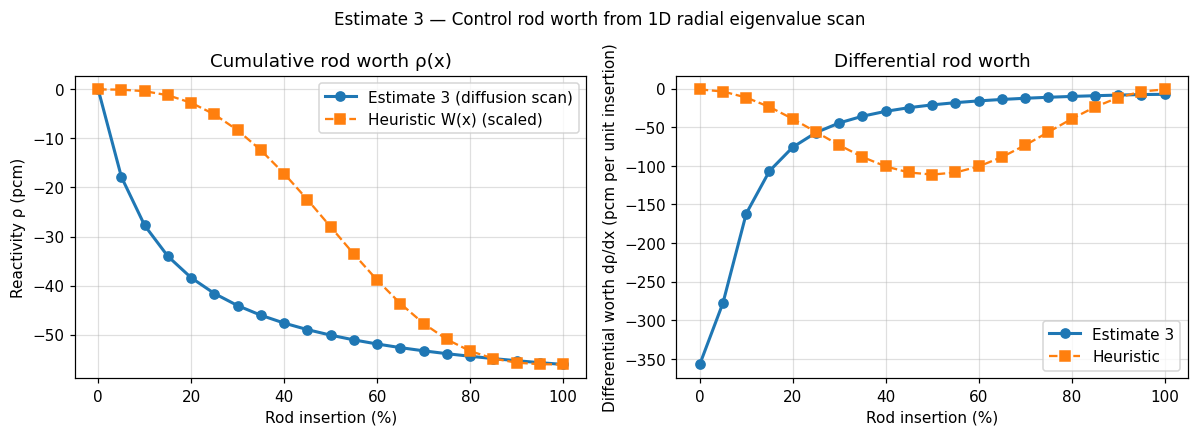


Key observations:
  Full-insertion worth = -56.1 pcm
  Differential worth at 50% insertion = -20.9 pcm per unit x

  The diffusion-derived worth curve differs from the heuristic because:
  1. The heuristic W(x) was constructed to be S-shaped by analogy with axial flux shape.
  2. The 1D radial model captures radial flux redistribution as the rod is inserted,
     but not the axial cosine weighting that the heuristic is based on.
  3. For an accurate axial rod worth, a 2D r-z eigenvalue solve is needed.


In [15]:
# ── Plot rod worth curve: diffusion vs heuristic ─────────────────────────────
x_arr    = np.array(insertion_values)
rho_arr  = np.array(rho_values)
rho_h_arr= np.array(rho_heuristic)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: Integral worth curves
ax = axes[0]
ax.plot(x_arr * 100, rho_arr,   'o-', lw=2,  label="Estimate 3 (diffusion scan)")
ax.plot(x_arr * 100, rho_h_arr, 's--', lw=1.5, label="Heuristic W(x) (scaled)")
ax.set_xlabel("Rod insertion (%)")
ax.set_ylabel("Reactivity ρ (pcm)")
ax.set_title("Cumulative rod worth ρ(x)")
ax.legend()

# Right: Differential worth dρ/dx
drho_dx  = np.gradient(rho_arr,  x_arr)
drho_h   = np.gradient(rho_h_arr, x_arr)

ax2 = axes[1]
ax2.plot(x_arr * 100, drho_dx, 'o-', lw=2, label="Estimate 3")
ax2.plot(x_arr * 100, drho_h,  's--', lw=1.5, label="Heuristic")
ax2.set_xlabel("Rod insertion (%)")
ax2.set_ylabel("Differential worth dρ/dx (pcm per unit insertion)")
ax2.set_title("Differential rod worth")
ax2.legend()

plt.suptitle("Estimate 3 — Control rod worth from 1D radial eigenvalue scan", fontsize=11)
plt.tight_layout()
plt.show()

# Print interpretation
diff_at_50 = np.interp(0.5, x_arr, drho_dx)
print("\nKey observations:")
print(f"  Full-insertion worth = {rho_total_E3:.1f} pcm")
print(f"  Differential worth at 50% insertion = {diff_at_50:.1f} pcm per unit x")
print()
print("  The diffusion-derived worth curve differs from the heuristic because:")
print("  1. The heuristic W(x) was constructed to be S-shaped by analogy with axial flux shape.")
print("  2. The 1D radial model captures radial flux redistribution as the rod is inserted,")
print("     but not the axial cosine weighting that the heuristic is based on.")
print("  3. For an accurate axial rod worth, a 2D r-z eigenvalue solve is needed.")

## 5. Estimate 4 — 2D *r*–*z* Diffusion Model *(primary rigorous result)*

This is the notebook's most complete model.  
It solves the full 2D $r$–$z$ diffusion eigenvalue problem on a finite-difference mesh,  
capturing **axial leakage** ($-271$ pcm sub-criticality), the **geometric rod cylinder**  
(tip at the real axial position), and the **S-shaped differential worth curve** that  
axial flux weighting produces.


### Why the 1D radial model is insufficient for rod worth

Estimate 3 represents partial rod insertion as a **scaled absorption** spread uniformly over
the full core height:

$$\Sigma_a^{\text{rod}}(r, x) = \Sigma_{a,D_2O} + x \cdot \Delta\Sigma_a^{\max},
\quad r < r_{\text{rod}}$$

Because $x$ only scales the material strength — not the axial position — the rod's
effectiveness at every axial location changes identically with insertion depth.  
Two direct consequences:

1. **No actual geometry**: a 50 %-inserted rod looks like a full-length rod with half the
   absorption, not like a rod whose tip is at the core midplane.
2. **Nearly linear worth curve**: without axial flux weighting, $\rho(x) \approx x \cdot
   \rho_{\text{full}}$, missing the S-shape that real reactors exhibit.

The correct calculation weights the rod's worth by the local neutron flux at the rod tip's
actual axial position.  This requires solving the 2D diffusion equation with the rod as a
true geometric cylinder:

$$r < r_{\text{rod}} \quad \text{and} \quad z > \tfrac{H}{2} - x \cdot H$$

### 2D r-z diffusion equation

With azimuthal symmetry ($\partial/\partial\theta = 0$) the one-group diffusion equation is:

$$-\frac{1}{r}\frac{\partial}{\partial r}\!\left(r\,D\,\frac{\partial\phi}{\partial r}\right)
  -\frac{\partial}{\partial z}\!\left(D\,\frac{\partial\phi}{\partial z}\right)
  + \Sigma_a\,\phi = \frac{1}{k}\,\nu\Sigma_f\,\phi$$

Material coefficients vary by region in **both** $r$ and $z$:

| Region | Radial | Axial |
|---|---|---|
| Inner D₂O moderator | $r < R_{\text{inner}}$ (no rod) | $\|z\| < H/2$ |
| Control rod | $r < r_{\text{rod}}$, inserted | $\|z\| < H/2$ |
| Fuel annulus | $R_{\text{inner}} < r < R_{\text{fuel}}$ | $\|z\| < H/2$ |
| Radial D₂O reflector | $R_{\text{fuel}} < r < R_{\text{extrap}}$ | $\|z\| < H/2$ |
| Axial D₂O reflectors | $0 < r < R_{\text{extrap}}$ | $H/2 < \|z\| < H_{\text{extrap}}/2$ |

**Boundary conditions:** zero-flux at the extrapolated boundary  
($r = R_{\text{extrap}}$, $|z| = H_{\text{extrap}}/2$); symmetry ($\partial\phi/\partial r = 0$) at $r = 0$.


In [16]:
# ── Estimate 4: 2D r-z model setup ───────────────────────────────────────────
# Model2D is imported from reactor_backend.diffusion; the notebook keeps the
# specific geometry choices and interpretation here.

# Build Model2D from Estimate 2 critical geometry
H_active  = 2.0 * critical_model.R_fuel                    # H = 2R aspect ratio (~606 cm)
H_refl_ax = critical_model.R_refl - critical_model.R_fuel  # 60 cm axial reflector per side

model_2d = Model2D(
    base    = critical_model,
    H       = H_active,
    H_refl  = H_refl_ax,
    r_rod   = r_rod,         # 10 cm from Estimate 3
    dSa_rod = dSa_rod_max,   # 0.090 cm^-1 from Estimate 3
)

print("Estimate 4 — 2D model geometry:")
print(f"  Active core:     R_fuel = {critical_model.R_fuel:.1f} cm,  H = {H_active:.1f} cm")
print(f"  Radial reflector:  {H_refl_ax:.1f} cm thick D2O")
print(f"  Axial reflectors:  {H_refl_ax:.1f} cm thick D2O (top + bottom)")
print(f"  R_extrap = {model_2d.R_extrap:.2f} cm,  H_extrap = {model_2d.H_extrap:.2f} cm")
print(f"  Control rod: r < {r_rod:.1f} cm, inserted from top")


Estimate 4 — 2D model geometry:
  Active core:     R_fuel = 303.0 cm,  H = 606.0 cm
  Radial reflector:  60.0 cm thick D2O
  Axial reflectors:  60.0 cm thick D2O (top + bottom)
  R_extrap = 365.45 cm,  H_extrap = 730.90 cm
  Control rod: r < 10.0 cm, inserted from top


In [17]:
# ── 2D r-z finite-difference eigenvalue solver ───────────────────────────────
# Sparse matrix assembly and power iteration now live in
# backend/reactor_backend/diffusion.py for reuse outside the notebook.

# Grid size check
_L, _, _rg, _zg, Nr_t, Nz_t = build_2d_matrices(model_2d, 3.0, 3.0, 0.0)
print(f"2D solver ready.  Grid at dr=dz=3 cm: Nr={Nr_t}, Nz={Nz_t}, N={Nr_t*Nz_t:,}  —  L nnz={_L.nnz:,}")
del _L, _rg, _zg


2D solver ready.  Grid at dr=dz=3 cm: Nr=122, Nz=244, N=29,768  —  L nnz=148,108


Solving unrodded 2D core …


  k_eff  = 0.997298  (177 iterations, 0.3 s)
  rho_0  = -271 pcm

  k_eff < 1 is expected: the 1D radial model (Est.2) sized the core for radial
  criticality only, without axial leakage. Adding the axial dimension introduces
  extra neutron loss, making the same geometry slightly sub-critical in 2D.


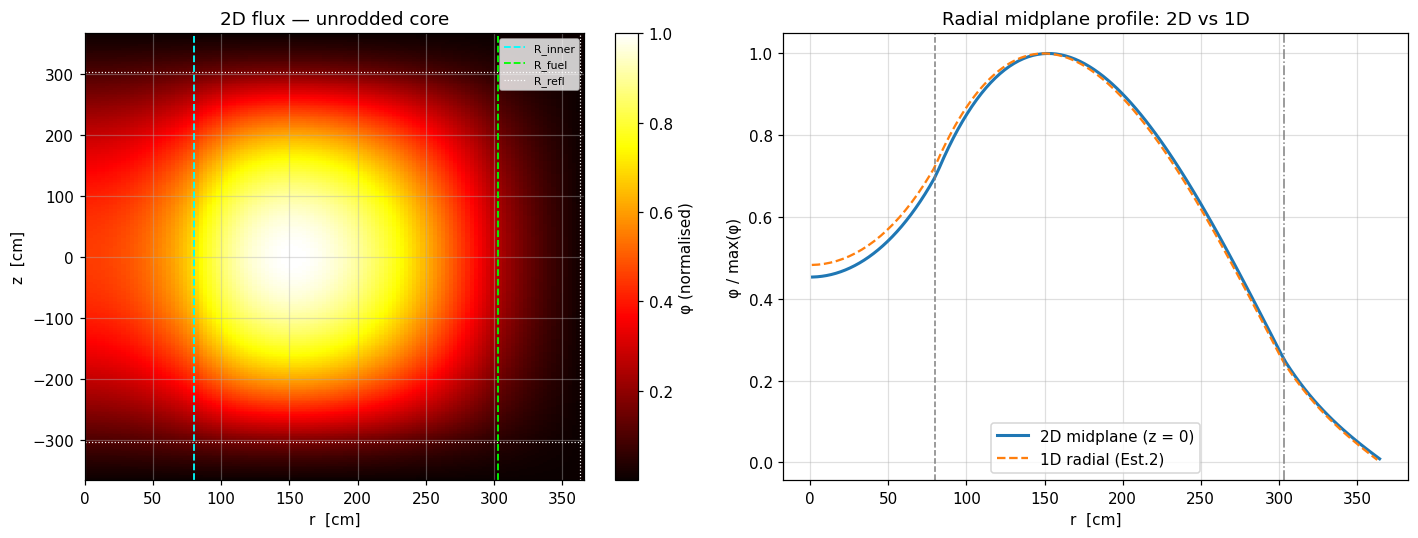

In [18]:
# ── Solve unrodded 2D core: k_eff and flux map ────────────────────────────────
import time

print("Solving unrodded 2D core …")
t0 = time.time()
sol_2d_0 = solve_2d(model_2d, dr=3.0, dz=3.0, x_insert=0.0, max_iter=500)
dt = time.time() - t0

k_2d_0  = sol_2d_0['k_eff']
rho_2d_clean_pcm = (k_2d_0 - 1.0) / k_2d_0 * 1e5
print(f"  k_eff  = {k_2d_0:.6f}  ({sol_2d_0['iterations']} iterations, {dt:.1f} s)")
print(f"  rho_0  = {rho_2d_clean_pcm:+.0f} pcm")
print()
print("  k_eff < 1 is expected: the 1D radial model (Est.2) sized the core for radial")
print("  criticality only, without axial leakage. Adding the axial dimension introduces")
print("  extra neutron loss, making the same geometry slightly sub-critical in 2D.")

phi_2d = sol_2d_0['phi']
r_g    = sol_2d_0['r_grid']
z_g    = sol_2d_0['z_grid']

# ── 2D colour map and radial midplane comparison with 1D ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.pcolormesh(r_g, z_g, phi_2d.T, cmap='hot', shading='auto')
ax.axvline(model_2d.base.R_inner, color='cyan',  lw=1.2, ls='--', label='R_inner')
ax.axvline(model_2d.base.R_fuel,  color='lime',  lw=1.2, ls='--', label='R_fuel')
ax.axvline(model_2d.base.R_refl,  color='white', lw=0.8, ls=':',  label='R_refl')
ax.axhline( model_2d.H / 2, color='white', lw=0.8, ls=':')
ax.axhline(-model_2d.H / 2, color='white', lw=0.8, ls=':')
plt.colorbar(im, ax=ax, label='φ (normalised)')
ax.set_xlabel('r  [cm]'); ax.set_ylabel('z  [cm]')
ax.set_title('2D flux — unrodded core')
ax.legend(fontsize=7, loc='upper right')

ax2 = axes[1]
iz_mid = sol_2d_0['Nz'] // 2
ax2.plot(r_g, phi_2d[:, iz_mid], lw=2, label='2D midplane (z = 0)', color='tab:blue')
r_1d  = np.array(sol_critical['radii'])
phi_1d = np.array(sol_critical['flux'])
ax2.plot(r_1d, phi_1d, '--', lw=1.5, color='tab:orange', label='1D radial (Est.2)')
ax2.axvline(model_2d.base.R_inner, color='gray', lw=1, ls='--')
ax2.axvline(model_2d.base.R_fuel,  color='gray', lw=1, ls='-.')
ax2.set_xlabel('r  [cm]'); ax2.set_ylabel('φ / max(φ)')
ax2.set_title('Radial midplane profile: 2D vs 1D')
ax2.legend()
plt.tight_layout()
plt.show()


Scanning rod insertion fraction (2D, dr=dz=3 cm) …
  x=0.0: k=0.997303  (5 iters)


  x=0.1: k=0.997296  (20 iters)


  x=0.2: k=0.997269  (23 iters)
  x=0.3: k=0.997222  (22 iters)


  x=0.4: k=0.997160  (21 iters)


  x=0.5: k=0.997089  (19 iters)
  x=0.6: k=0.997018  (18 iters)


  x=0.7: k=0.996950  (18 iters)


  x=0.8: k=0.996902  (17 iters)
  x=0.9: k=0.996876  (16 iters)


  x=1.0: k=0.996871  (12 iters)
Scan time: 0.8 s


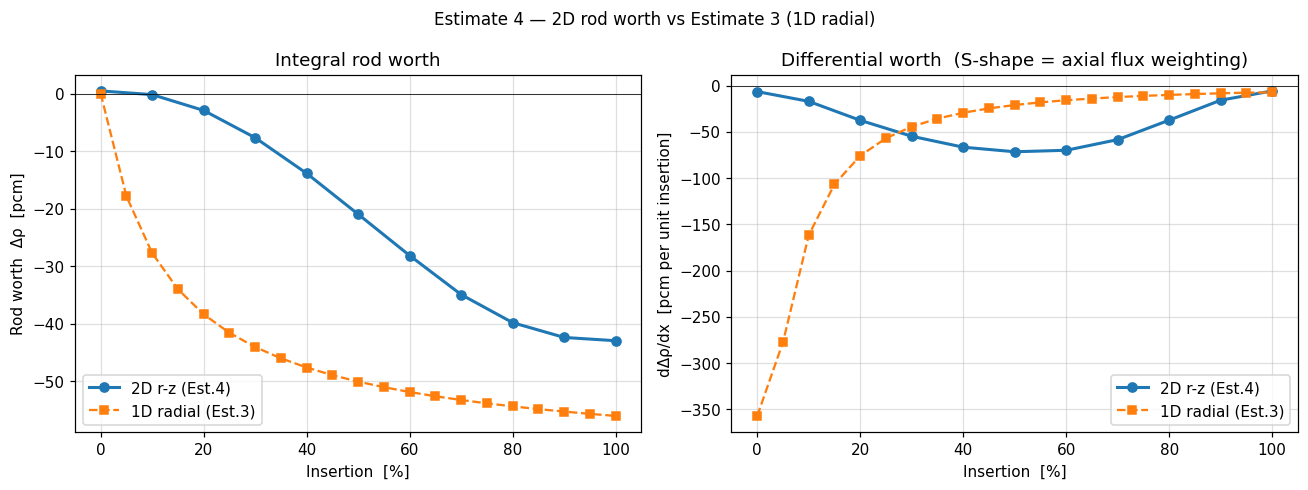


Full-insertion rod worth:
  2D r-z   = -43.0 pcm
  1D radial = -56.1 pcm

  The differential worth curve (right panel) peaks near 50% insertion,
  reflecting the cosine-shaped axial flux weighting. This S-shape is absent
  in the 1D model because it does not resolve axial position.


In [19]:
# ── 2D rod worth scan: insertion 0 → 100 % ───────────────────────────────────
# Reactivity worth relative to unrodded 2D reference:
#   Delta_rho(x) = rho(k(x)) - rho(k_2d_0)
#   where rho(k) = (k - 1) / k  (exact definition, in pcm x 1e5)

x_2d   = np.linspace(0, 1, 11)    # 0 %, 10 %, …, 100 % insertion
k_2d   = np.zeros(len(x_2d))
phi_ws = sol_2d_0['phi']           # warm-start from unrodded flux
k_2d_ref = k_2d_0                    # reference: unrodded 2D k_eff

print("Scanning rod insertion fraction (2D, dr=dz=3 cm) …")
t0 = time.time()
for ix, x in enumerate(x_2d):
    sol_x    = solve_2d(model_2d, dr=3.0, dz=3.0, x_insert=x,
                        phi0=phi_ws, max_iter=200, tol=1e-6)
    k_2d[ix] = sol_x['k_eff']
    phi_ws   = sol_x['phi']    # warm start for next step
    print(f"  x={x:.1f}: k={k_2d[ix]:.6f}  ({sol_x['iterations']} iters)")

print(f"Scan time: {time.time()-t0:.1f} s")

# Rod worth relative to unrodded 2D baseline
rho_2d_worth = np.array([((k - 1.0) / k - (k_2d_0 - 1.0) / k_2d_0) * 1e5 for k in k_2d])   # pcm

# ── Comparison plot: 2D vs 1D rod worth ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(x_2d * 100, rho_2d_worth,  'o-',  lw=2, ms=6, label='2D r-z (Est.4)')
ax1.plot(x_arr * 100, rho_arr,       's--', lw=1.5, ms=5, label='1D radial (Est.3)')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel('Insertion  [%]'); ax1.set_ylabel('Rod worth  Δρ  [pcm]')
ax1.set_title('Integral rod worth')
ax1.legend()

drho_2d = np.gradient(rho_2d_worth, x_2d)
drho_1d = np.gradient(rho_arr,      x_arr)

ax2.plot(x_2d * 100, drho_2d, 'o-',  lw=2, ms=6, label='2D r-z (Est.4)')
ax2.plot(x_arr * 100, drho_1d, 's--', lw=1.5, ms=5, label='1D radial (Est.3)')
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xlabel('Insertion  [%]')
ax2.set_ylabel('dΔρ/dx  [pcm per unit insertion]')
ax2.set_title('Differential worth  (S-shape = axial flux weighting)')
ax2.legend()

plt.suptitle('Estimate 4 — 2D rod worth vs Estimate 3 (1D radial)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nFull-insertion rod worth:")
print(f"  2D r-z   = {rho_2d_worth[-1]:+.1f} pcm")
print(f"  1D radial = {rho_arr[-1]:+.1f} pcm")
print()
print("  The differential worth curve (right panel) peaks near 50% insertion,")
print("  reflecting the cosine-shaped axial flux weighting. This S-shape is absent")
print("  in the 1D model because it does not resolve axial position.")


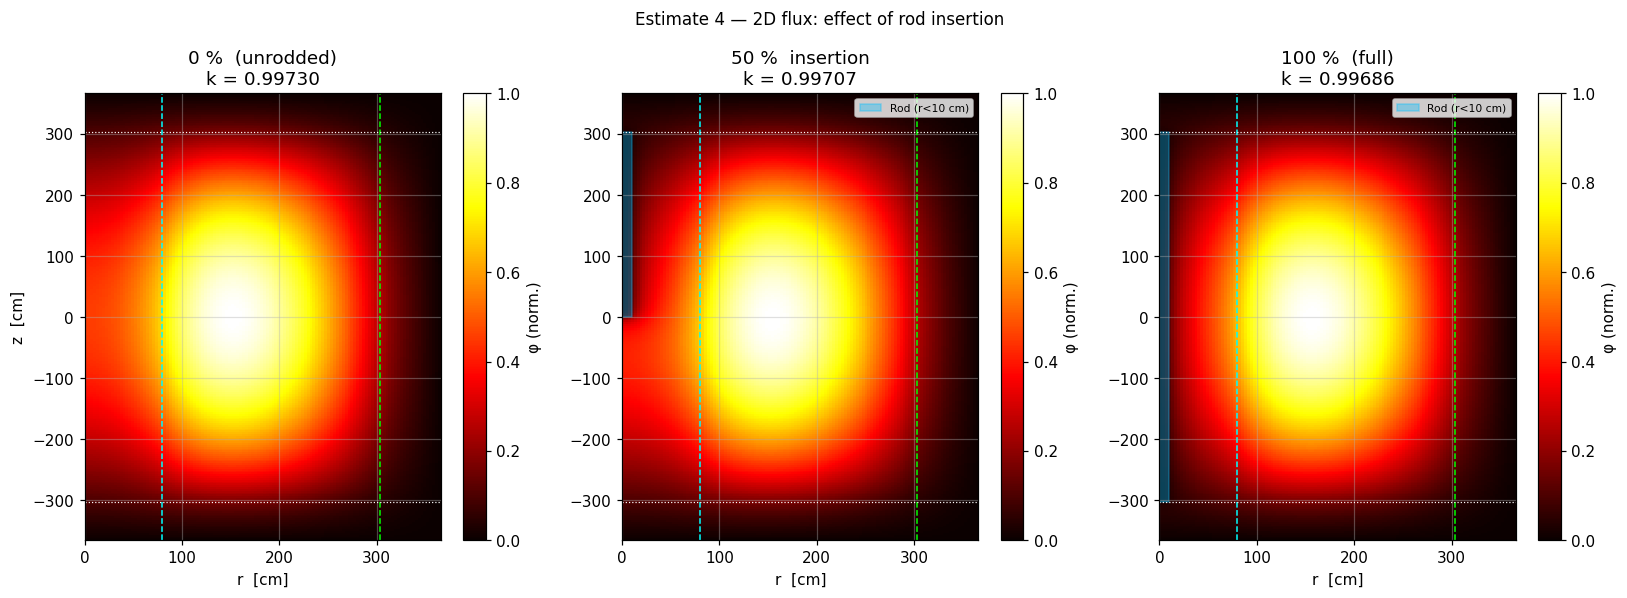

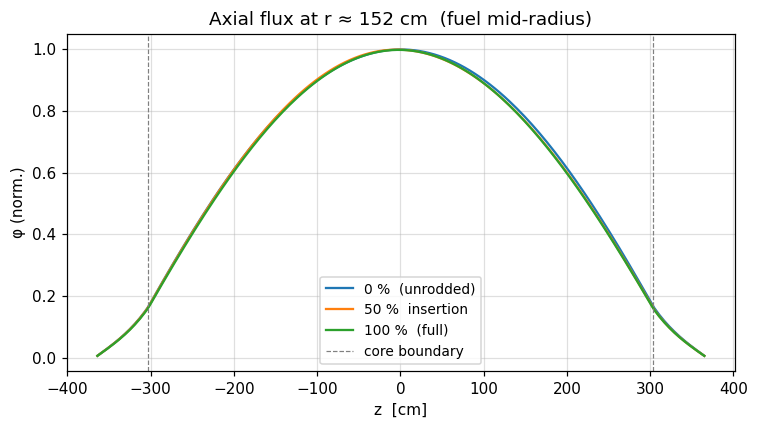

In [20]:
# ── 2D flux maps: unrodded, 50%, fully rodded ────────────────────────────────
insertions_viz = [0.0, 0.5, 1.0]
labels_viz     = ['0 %  (unrodded)', '50 %  insertion', '100 %  (full)']

sols_viz  = [sol_2d_0]                # x=0 already computed
phi_warm2 = sol_2d_0['phi']
for xi in insertions_viz[1:]:
    s = solve_2d(model_2d, dr=3.0, dz=3.0, x_insert=xi,
                 phi0=phi_warm2, max_iter=80, tol=1e-6)
    sols_viz.append(s)
    phi_warm2 = s['phi']

vmax = max(s['phi'].max() for s in sols_viz)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, sol, lbl, xi in zip(axes, sols_viz, labels_viz, insertions_viz):
    phi_v = sol['phi']
    r_v   = sol['r_grid'];  z_v = sol['z_grid']
    im = ax.pcolormesh(r_v, z_v, phi_v.T, cmap='hot', shading='auto',
                       vmin=0, vmax=vmax)
    ax.axvline(model_2d.base.R_inner, color='cyan',  lw=1, ls='--')
    ax.axvline(model_2d.base.R_fuel,  color='lime',  lw=1, ls='--')
    ax.axhline( model_2d.H / 2, color='white', lw=0.8, ls=':')
    ax.axhline(-model_2d.H / 2, color='white', lw=0.8, ls=':')
    if xi > 0:
        z_tip = model_2d.H / 2 - xi * model_2d.H
        ax.fill_betweenx([z_tip, model_2d.H / 2], 0, model_2d.r_rod,
                          alpha=0.35, color='deepskyblue',
                          label=f'Rod (r<{model_2d.r_rod:.0f} cm)')
        ax.legend(fontsize=7, loc='upper right')
    plt.colorbar(im, ax=ax, label='φ (norm.)')
    ax.set_xlabel('r  [cm]')
    ax.set_ylabel('z  [cm]' if ax is axes[0] else '')
    ax.set_title(f'{lbl}\nk = {sol["k_eff"]:.5f}')

plt.suptitle('Estimate 4 — 2D flux: effect of rod insertion', fontsize=11)
plt.tight_layout()
plt.show()

# Axial profile at fuel mid-radius
r_probe = model_2d.base.R_fuel / 2
ir      = np.argmin(np.abs(sols_viz[0]['r_grid'] - r_probe))
fig2, ax3 = plt.subplots(figsize=(7, 4))
for sol, lbl in zip(sols_viz, labels_viz):
    ax3.plot(sol['z_grid'], sol['phi'][ir, :], label=lbl)
ax3.axvline( model_2d.H / 2, color='gray', lw=0.8, ls='--', label='core boundary')
ax3.axvline(-model_2d.H / 2, color='gray', lw=0.8, ls='--')
ax3.set_xlabel('z  [cm]'); ax3.set_ylabel('φ (norm.)')
ax3.set_title(f'Axial flux at r ≈ {sols_viz[0]["r_grid"][ir]:.0f} cm  (fuel mid-radius)')
ax3.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 6. Comparison and Path to Point-Kinetics Coupling

### Summary of four estimates

| Quantity | Estimate 1 (homog.) | Estimate 2 (piecewise 1D) | Estimate 3 (rodded 1D) | Estimate 4 (2D r-z) |
|---|---|---|---|---|
| $R_{\text{fuel}}$ critical | ~330 cm (w/ savings) | **303 cm** (exact) | — (uses E2 geometry) | — (uses E2 geometry) |
| Peak flux (20 MW) | ~3.3×10¹² n/cm²/s | ~1.5×10¹² n/cm²/s | — | — |
| Unrodded $k_{\text{eff}}$ | ~1 (by construction) | 0.9999 (1D, radial only) | 0.9999 (1D) | **0.9973** (full 3D leakage) |
| Axial leakage | ✗ flat axial assumption | ✗ | ✗ | ✓ $-271$ pcm sub-critical |
| Rod insertion model | — | — | height-averaged $\Sigma_a$ | ✓ geometric cylinder |
| Rod worth at 100% | — | — | $-56$ pcm (1D radial) | **$-43$ pcm** (2D r-z) |
| Differential worth curve | — | — | nearly linear | ✓ S-shape (axial flux weighting) |
| Inner void captured | ✗ | ✓ | ✓ | ✓ |
| Reflector captured | only via savings | ✓ exact BC | ✓ | ✓ |

### Key physical insights from Estimate 4

**Axial leakage makes the geometry sub-critical.**
The 1D radial model sized the core for $k_{\text{eff}} = 1$ using only the radial buckling.
Adding the axial dimension introduces ~271 pcm of extra leakage, pushing the clean core to
$k_{\text{eff}} = 0.9973$.  To achieve actual criticality the reactor would need a slightly
larger fuel annulus, a taller core, or enrichment adjustment.

**Rod worth differs by ~30% between 1D and 2D.**
The 1D estimate (−56 pcm) distributes extra absorption uniformly over the full height,
overestimating the rod's effectiveness when partially inserted. The 2D solve gives −43 pcm
for full insertion, with the correct axial geometric dependence.

**The S-shaped differential worth curve.** 
In the 2D model the differential worth $d\Delta\rho/dx$ peaks near 50–60% insertion and
falls near both fully-withdrawn and fully-inserted positions — consistent with the cosine
axial flux shape weighting the absorber's local effectiveness.  The 1D model cannot
produce this behaviour.

### Most uncertain inputs

1. **Fuel $\Sigma_a$** (8.5×10⁻³ cm⁻¹): the resonance-absorption correction is a factor
   of ~3 above the 2200 m/s value.  Lattice physics codes (DRAGON, Serpent) would
   give the correct self-shielded value.

2. **Rod $\Delta\Sigma_a$**: a real rod requires absorber self-shielding corrections.  The
   2D solve correctly captures axial flux weighting but still uses the same homogenised
   $\Delta\Sigma_a$ value.

3. **Enrichment / spectrum**: one-group constants averaged over a thermal spectrum are
   approximate. Multi-group transport would resolve the fast/thermal coupling important
   for Doppler feedback.

### How to couple Estimate 4 back to the point-kinetics transient model

1. Replace the heuristic $W(x) = x - \sin(2\pi x)/(2\pi)$ with the 2D-computed $\Delta\rho(x)$ table.
2. Interpolate $\Delta\rho(x)$ in the transient engine for any rod insertion depth.
3. The nominal flux $\Phi_0$ from Estimate 2 replaces the empirical flux constant in the backend.
4. The **prompt generation time** $\Lambda$ still requires a separate adjoint solve.

### Next modelling steps

- **Multi-group model**: resolves thermal/fast spectral coupling, important for Doppler feedback
- **Xenon transient**: coupled iodine/xenon burnup for long-term reactivity feedback
- **Thermal-hydraulic feedback**: Doppler and coolant void coefficients
- **Adjoint solve**: rigorous $\Lambda$, effective delayed neutron fraction $\beta_{\text{eff}}$
